# Task 2.1 — Dataset Selection and Setup

In this task we select an appropriate dataset to reproduce the method proposed in the selected research paper. The objective is to demonstrate sentiment classification using TF-IDF based document representation on a toy dataset.

---

## Dataset Selection

For this experiment we use the **IMDB Movie Review Dataset**, a widely used benchmark dataset for sentiment classification. The dataset contains **50,000 movie reviews** labeled as positive or negative sentiment.

The dataset is appropriate for this study because the selected research paper addresses **binary sentiment classification using document representations based on TF-IDF weighting schemes**. IMDB reviews are long textual documents where many words appear multiple times, making **term frequency (tf) meaningful**, which is important because the paper's contribution studies improved weighting schemes such as **sublinear TF scaling and Delta IDF**.

Although the paper also evaluates a movie review dataset, the IMDB dataset is **a different corpus collected independently**, containing different reviews, authors, and collection methodology. Therefore it allows the proposed method to be tested on a **new dataset while maintaining the same problem type**.

A subset of **2000 reviews (1000 per class)** is sampled from the full dataset to create a manageable toy dataset. This size roughly matches the scale of the movie review dataset used in the paper, allowing loose comparison while keeping the experiment computationally lightweight.

### Why this dataset is appropriate

The selected research paper studies **sentiment classification using document representation and weighting schemes such as TF-IDF and Delta TF-IDF**. The IMDB dataset contains opinionated movie reviews labeled with sentiment polarity, making it suitable for demonstrating how TF-IDF weighting affects sentiment classification performance.

### Difference from the dataset used in the paper

Its main limitation compared to the paper's datasets is that it covers only one domain (movies), whereas the paper validates across movies, product reviews, and blogs — meaning cross-domain generalisation cannot be tested here.

---

In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

train_data = dataset["train"]

df = pd.DataFrame({
    "review": train_data["text"],
    "sentiment": train_data["label"]
})

print(df.head())

                                              review  sentiment
0  I rented I AM CURIOUS-YELLOW from my video sto...          0
1  "I Am Curious: Yellow" is a risible and preten...          0
2  If only to avoid making this type of film in t...          0
3  This film was probably inspired by Godard's Ma...          0
4  Oh, brother...after hearing about this ridicul...          0


### Dataset Loading

The IMDB dataset is loaded using the HuggingFace `datasets` library.  
Each record in the dataset contains:

- `text` → the movie review
- `label` → sentiment polarity (0 = negative, 1 = positive)

The dataset is converted into a **pandas DataFrame** to simplify data inspection and further processing.

---

In [3]:
df = df.sample(n=2000, random_state=42)

# Save toy dataset for later notebooks
df.to_csv("data/imdb_toy_dataset.csv", index=False)

print("Toy dataset saved successfully")
print("Shape:", df.shape)

Toy dataset saved successfully
Shape: (2000, 2)


### Toy Dataset Creation

The original IMDB dataset contains 50,000 reviews.  
For this experiment we randomly sample **2000 reviews (1000 per class)** to create a smaller toy dataset.

This size was chosen because it roughly matches the scale of the **2000-review movie dataset used in the paper**, making results loosely comparable while keeping computation lightweight.

---

In [18]:
df["sentiment"].value_counts()

sentiment
0    1040
1     960
Name: count, dtype: int64

### Dataset Class Distribution

The dataset contains two sentiment classes:

- Negative reviews (label = 0)
- Positive reviews (label = 1)

Checking the class distribution ensures that the dataset is reasonably balanced and suitable for training a sentiment classifier.

---

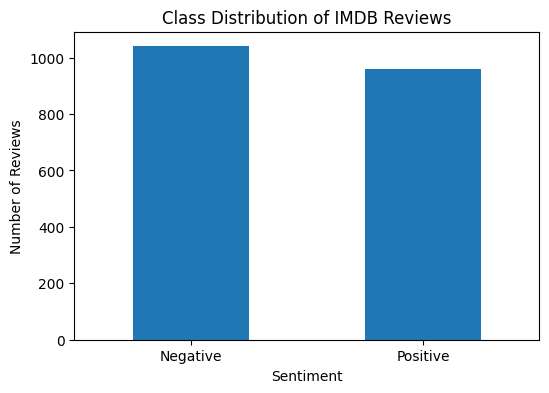

In [4]:
import matplotlib.pyplot as plt

counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind="bar")

plt.title("Class Distribution of IMDB Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0,1], ["Negative","Positive"], rotation=0)

plt.show()

### Class Distribution Visualization

The bar chart above shows the number of positive and negative reviews in the dataset.  
A balanced dataset helps ensure that the classifier does not become biased toward one class during training.

---

## Preprocessing Plan

Before applying the machine learning model, the text data will undergo basic preprocessing steps:

1. Convert text to lowercase.
2. Remove punctuation and non-alphabetic characters.
3. Tokenize the text into individual words.
4. Convert documents into numerical feature vectors using **TF-IDF weighting**.

These preprocessing steps prepare the textual data for sentiment classification and will be implemented in **Task 2.2**, 

---

### Dataset Availability

The dataset is loaded using the HuggingFace `datasets` library for convenience.  
For reproducibility, a local copy of the processed dataset is being stored inside the repository under `partB/data/`.

This ensures the notebook can run even if the HuggingFace dataset loader is unavailable.